---
title: Tracks widget
---

In [21]:
import numpy as np
import pandas as pd
from time import sleep
import pyarrow.parquet as pq
from pathlib import Path
import pickle
from collections import OrderedDict
from geneinfo.widget import Tracks
from vscodenb import set_vscode_theme
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
sns.set_palette('tab10')
set_vscode_theme()

## Dummy quantitative data

In [22]:
#| echo: false

from geneinfo.coords import chromosome_lengths
from geneinfo.information import gene_info

chrom_sizes = dict(chromosome_lengths('hg38'))

from geneinfo.genelist import GeneList as glist
from geneinfo.genelist import GeneListCollection
sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')

from geneinfo.coords import chromosome_lengths, gene_coords
chrom_sizes = dict(chromosome_lengths(assembly='hg38'))

rng = np.random.default_rng(42)
quant_rows = []
n_points = 1000
for chrom, csz in chrom_sizes.items():
    positions = np.sort(rng.integers(0, csz, n_points))
    fst = np.abs(rng.normal(0.05, 0.08, n_points)).clip(0, 1)
    rate = np.cumsum(rng.normal(0, 0.3, n_points))
    rate = (rate - rate.min()) / (rate.max() - rate.min()) * 5 + 0.5
    mid = np.cumsum(rng.normal(0, 0.15, n_points))
    eig = np.sin(positions / 1e7 * 2 * np.pi) + rng.normal(0, 0.2, n_points)
    ci_lo = mid - rng.exponential(0.3, n_points)
    ci_hi = mid + rng.exponential(0.3, n_points) + 10
    depth = rng.poisson(30, n_points).astype(float)

    for pop in ['AFR', 'EUR']:
        noise = rng.normal(0, 0.02, n_points)
        for i in range(n_points):
            quant_rows.append({
                'chrom': chrom, 'pos': int(positions[i]),
                'fst': float(fst[i] + noise[i]),
                'rate': float(rate[i] + noise[i] * 10) + (5 if pop == 'EUR' else 0),
                'eig': float(eig[i] + noise[i]),
                'ci_lo': float(ci_lo[i]) + (15 if pop == 'EUR' else 0), 
                'ci_hi': float(ci_hi[i]) + (15 if pop == 'EUR' else 0), 
                'depth': float(depth[i] + rng.normal(0, 3)),
                'pop': pop,
            })
qdf = pd.DataFrame(quant_rows)            

## Gene track

In [23]:
Tracks('hg38').add_gene_track()

## Widget Controls

**Toolbar (left-to-right):**
- **Chromosome dropdown** — switch chromosome.
- **Position box** — type a coordinate (`50000000`) or range (`chr1:1e6-2e6`) and press Enter. Invalid input flashes the box red with a tooltip hint.
- **＋ / −** — zoom in / out (cursor-anchored in the plot).
- **«  ‹  ›  »** — pan left / right by 90 % / 50 % of the view.
- **⌂** — reset to the full chromosome.
- **⟲** — recompute heatmap(s) at the current view for higher resolution. Shows a spinner while rebin is in flight. *(heatmap tracks only)*
- **◱** — restore the whole-chromosome heatmap view. *(heatmap tracks only)*
- **A** — show all gene labels when fewer than 100 genes are visible. *(gene tracks only)*
- **⧉** — snapshot the current view. Flashes **✓** if copied to the clipboard, **⇓** if downloaded as a PNG fallback, **!** on failure.
- **?** — help popover listing mouse, keyboard, and toolbar controls. `Esc` or click-outside to dismiss.
- **▬ segments / ▒ density** badge — LOD indicator.

**Mouse:**
- **Drag** on the plot to pan.
- **Scroll wheel** to zoom (anchored on the cursor's genomic position).
- **Double-click** to zoom in 2× centred on the click.
- **Hover** for a context-sensitive tooltip (gene name, y-value, group, individual, ...).

**Keyboard (when the widget has focus):**
- **← / →** — pan by 15 % of the current view.
- **+ / =** — zoom in 1.5×.  **−** — zoom out 1.5×.

**Python:**
- `viewer.zoom_to(chrom, center=..., window=...)` — jump programmatically. Raises `KeyError` for unknown chromosomes.
- `viewer.set_viewport(chrom, start, end)` — set the viewport directly; clamps out-of-range start/end, raises `KeyError` for unknown chromosomes.
- `viewer.viewport` — read the current `{chrom, start, end}` (updates on pan/zoom settle).
- `viewer.remove_track(name_or_index)` / `viewer.clear_tracks()` — remove tracks in place.
- `viewer.zoom_speed = 1.02` — tune wheel-zoom sensitivity.

## Highlighting

### Simple

In [24]:
(
    Tracks('hg38')
    .add_gene_track(highlight=['LRRC7', 'LRRC40', 'CTH', 'SRSF11', 'CTH'], 
                    highlight_color="#ee55c5",
                    )
).zoom_to('chr1', center=70000000, window=1200000) # zoom to region interest for demonstration purposes

### Combinatorial

In [25]:
(
    Tracks(chrom_sizes)
    .add_gene_track(assembly='hg38',
                    height = 100, 
                    highlight={                                                                   
                        'fill':      ['ANKRD13C', 'LRRC40', 'CTH'],                                           
                        'stroke':    ['LRRC40'],                                                     
                        'outline':   ['BRCA1'],                                                   
                        'color':     ['LRRC40'],                                                    
                        'bold':      ['LRRC7', 'LRRC40'],                                           
                        'italic':    ['ANKRD13C'],                                                     
                        'underline': ['CTH'],                                                    
                        'halo':      ['SRSF11'],                                                   
                    }, 
                    highlight_fill_color    = "#e03a4e",                  
                    highlight_spine_color   = "#d80ce6",                                          
                    highlight_outline_color = "#000000",                                          
                    highlight_label_color   = "#169f4a",                                          
                    highlight_halo_color    = "#79CAD32E",    
                    )
).zoom_to('chr1', center=70300000, window=600000) # zoom to region interest for demonstration purposes

## Read in archaic segments

In [43]:
meta = pq.ParquetFile('/Users/kmt/davide_segments_v2/dims/metadata.parquet').read().to_pandas()
meta.reg.unique()

# # subset_regs = ['AFR', 'EUR', 'EAS', 'SAS', 'MID', 'OCE', 'AMR']
# subset_regs = ['EUR', 'EAS', 'OCE']
# subset_meta = meta[(meta['sex'] == 'F') & meta['reg'].isin(subset_regs)].groupby('reg').head(1000)

# subset_meta = meta[meta['reg'].isin(['EUR', 'EAS', 'OCE'])].groupby('reg').head(50)
subset_meta = meta#[meta['reg'].isin(['AFR', 'EUR', 'EAS', 'SAS', 'MID', 'OCE', 'AMR'])]
#subset_meta = meta[meta['reg'].isin(['AMR'])].groupby('reg').head(5000)


frames = []
for ind in subset_meta['ind']:
    fp = Path(f'/Users/kmt/davide_segments_v2/fragments/phase_state=phased/ind={ind}/0.parquet')
    if fp.exists() and fp.stat().st_size:
        data = pq.ParquetFile(fp).read()
        frames.append(pq.ParquetFile(fp).read().to_pandas())
segments = pd.concat(frames, ignore_index=True)
segments['chrom'] = 'chr' + segments['chrom'].astype(str)
segments = segments.merge(meta[['ind', 'reg', 'pop', 'sex']], on='ind', how='left')
segments.columns

Index(['chrom', 'start', 'end', 'length', 'hap', 'mean_prob',
       'called_sequence', 'mutationrate', 'snps', 'admixpopvariants',
       'linkDAVC', 'Vindija', 'Chagyrskaya', 'Altai', 'Denisova',
       'private_Vindija', 'private_Chagyrskaya', 'private_Altai',
       'private_Denisova', 'shared_Neanderthal', 'shared_archaic', 'ancestry',
       'min_dist_anc', 'min_dist_value', 'z_test_anc', 'z_test_dist',
       'z_test_pval', 'ind', 'phase_state', 'reg', 'pop', 'sex'],
      dtype='str')

In [44]:

segments.to_parquet('segments.parquet')

print(f'{len(segments):,} segments from {segments["ind"].nunique()} individuals')
print(f'Mean length: {(segments["end"] - segments["start"]).mean():,.0f} bp')
print(f'Regions: {dict(segments.groupby("reg")["ind"].nunique())}')
print(f'Ancestries: {sorted(segments["ancestry"].unique())}')

region_colors={'AFR': "#d80019", 'EUR': "#0067cf", 'SAS': "#7e00bd", 'EAS': "#00a75f", 'MID': "#c20098", 'OCE': "#d19300", 'AMR': "#7e4e00"}
ancestry_colors={'Altai': 'green', 'Vindija': 'orange', 'Chagyrskaya': 'blue', 'AmbigNean': 'purple', 'Denisova': 'red', 'nonDAVC': 'gray'}

2,504,943 segments from 1147 individuals
Mean length: 63,215 bp
Regions: {'AMR': np.int64(277), 'EAS': np.int64(302), 'EUR': np.int64(304), 'OCE': np.int64(260), 'SAS': np.int64(4)}
Ancestries: ['Altai', 'AmbigNean', 'Ambiguous', 'Chagyrskaya', 'Denisova', 'Vindija', 'nonDAVC']


In [28]:
segments.loc[(segments['chrom']=='chr5') & (segments.start < 23422460) & (segments.end > 23549219)].style

,chrom,start,end,length,hap,mean_prob,called_sequence,mutationrate,snps,admixpopvariants,linkDAVC,Vindija,Chagyrskaya,Altai,Denisova,private_Vindija,private_Chagyrskaya,private_Altai,private_Denisova,shared_Neanderthal,shared_archaic,ancestry,min_dist_anc,min_dist_value,z_test_anc,z_test_dist,z_test_pval,ind,phase_state,reg,pop,sex
1880620,chr5,21957000,23741000,1784000,2,0.961780,1452851,1.145000,65,6,12,5,6,6,0,0,0,0,0,6,0,AmbigNean,Outgroup,0.001629,AMH,"1.6292e-03,2.5786e-03,3.1692e-03","5.00e-01,1.14e-53,2.67e-121",HG01108,phased,AMR,PUR,F


## Segment maps

### Density

In [29]:
from geneinfo.coords import gene_coords
gene_coords('PRDM9', assembly='hg38')

[('chr5', 23507154, 23528093, 'PRDM9')]

In [30]:
def gene_view(name, span=1000000):
    chrom, start, end, _ = gene_coords(name, assembly='hg38')[0]
    return dict(chrom=chrom, center=(start+end)/2, window=span)

gene_view('PRDM9')


{'chrom': 'chr5', 'center': 23517623.5, 'window': 1000000}

circRNA sponging miR-892b

- ZFAS1
- PTK2 (circ_0003221 / hsa_circ_0003221)
- DDX42 (circ_0007534)

In [31]:
sponges = glist(['ZFAS1', 'PTK2', 'DDX42'])
gene_info(sponges)

**Symbol:** **_ZFAS1_** (ncRNA) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** C20orf199, HSUP1, HSUP2, NCRNA00275, ZNFX1-AS1  
*ZNFX1 antisense RNA 1*  
**Summary:** This gene represents a snoRNA host gene that produces a non-coding RNA. Increased expression or amplification of this locus is associated with cancer progression and metastasis. This transcript regulates expression of genes involved in differentiation. It may act a molecular sponge for microRNAs. Alternatively spliced transcript variants have been observed. [provided by RefSeq, Dec 2017].  
**Human genomic position:** 20:49277054-49299600 (hg38), 20:47894715-47905797 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=ZFAS1)  


 ----

**Symbol:** **_PTK2_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** FADK, FADK 1, FAK, FAK1, FRNK, PPP1R71, p125FAK, pp125FAK  
*protein tyrosine kinase 2*  
**Summary:** This gene encodes a cytoplasmic protein tyrosine kinase which is found concentrated in the focal adhesions that form between cells growing in the presence of extracellular matrix constituents. The encoded protein is a member of the FAK subfamily of protein tyrosine kinases but lacks significant sequence similarity to kinases from other subfamilies. Activation of this gene may be an important early step in cell growth and intracellular signal transduction pathways triggered in response to certain neural peptides or to cell interactions with the extracellular matrix. Several transcript variants encoding different isoforms have been found for this gene. [provided by RefSeq, Jun 2017].  
**Human genomic position:** 8:140657900-141002216 (hg38), 8:141667999-142012315 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=PTK2)  


 ----

**Symbol:** **_DDX42_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** DDX42P, RHELP, RNAHP, SF3B8, SF3b125  
*DEAD-box helicase 42*  
**Summary:** This gene encodes a member of the Asp-Glu-Ala-Asp (DEAD) box protein family. Members of this protein family are putative RNA helicases, and are implicated in a number of cellular processes involving alteration of RNA secondary structure such as translation initiation, nuclear and mitochondrial splicing, and ribosome and spliceosome assembly. Members of this family are believed to be involved in embryogenesis, spermatogenesis, and cellular growth and division. Two transcript variants encoding the same protein have been identified for this gene. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 17:63773603-63819429 (hg38), 17:61850963-61896677 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=DDX42)  


 ----

In [32]:
gene_coords(sponges, assembly='hg38')

[('chr20', 49278177, 49289260, 'ZFAS1'),
 ('chr8', 140657899, 141002079, 'PTK2'),
 ('chr17', 63773799, 63819317, 'DDX42')]

In [33]:
go_meiosis_term = glist(['SMC1A', 'SMC3', 'MEI4', 'ANAPC15', 'ANAPC16', 'TOP2B', 'BTBD18'])
gene_info(go_meiosis_term)

**Symbol:** **_SMC1A_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** CDLS2, DEE85, DXS423E, EIEE85, SB1.8, SMC1, SMC1L1, SMC1alpha, SMCB  
*structural maintenance of chromosomes 1A*  
**Summary:** Proper cohesion of sister chromatids is a prerequisite for the correct segregation of chromosomes during cell division. The cohesin multiprotein complex is required for sister chromatid cohesion. This complex is composed partly of two structural maintenance of chromosomes (SMC) proteins, SMC3 and either SMC1B or the protein encoded by this gene. Most of the cohesin complexes dissociate from the chromosomes before mitosis, although those complexes at the kinetochore remain. Therefore, the encoded protein is thought to be an important part of functional kinetochores. In addition, this protein interacts with BRCA1 and is phosphorylated by ATM, indicating a potential role for this protein in DNA repair. This gene, which belongs to the SMC gene family, is located in an area of the X-chromosome that escapes X inactivation. Mutations in this gene result in Cornelia de Lange syndrome. Alternative splicing results in multiple transcript variants encoding different isoforms. [provided by RefSeq, Jul 2013].  
**Human genomic position:** X:53374149-53422728 (hg38), HG1433_PATCH:53117149-53165728, X:53401070-53449677 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=SMC1A)  


 ----

**Symbol:** **_SMC3_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** BAM, BMH, CDLS3, CSPG6, HCAP, SMC3L1  
*structural maintenance of chromosomes 3*  
**Summary:** This gene belongs to the SMC3 subfamily of SMC proteins. The encoded protein occurs in certain cell types as either an intracellular, nuclear protein or a secreted protein. The nuclear form, known as structural maintenance of chromosomes 3, is a component of the multimeric cohesin complex that holds together sister chromatids during mitosis, enabling proper chromosome segregation. Post-translational modification of the encoded protein by the addition of chondroitin sulfate chains gives rise to the secreted proteoglycan bamacan, an abundant basement membrane protein. [provided by RefSeq, Jul 2008].  
**Human genomic position:** 10:110567680-110606048 (hg38), 10:112327449-112364394 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=SMC3)  


 ----

**Symbol:** **_MEI4_** (protein-coding)  
*meiotic double-stranded break formation protein 4*  
**Summary:** Predicted to be involved in gamete generation and meiosis I cell cycle process. Predicted to be active in lateral element. [provided by Alliance of Genome Resources, Apr 2022]  
**Human genomic position:** 6:77650274-77927045 (hg38), 6:78400375-78636691 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=MEI4)  


 ----

**Symbol:** **_ANAPC15_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** APC15, C11orf51, HSPC020  
*anaphase promoting complex subunit 15*  
**Summary:** Involved in regulation of mitotic cell cycle spindle assembly checkpoint. Part of anaphase-promoting complex. [provided by Alliance of Genome Resources, Apr 2022]  
**Human genomic position:** 11:72106378-72113688 (hg38), 11:71817424-71823826 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=ANAPC15)  


 ----

**Symbol:** **_ANAPC16_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** APC16, C10orf104, CENP-27, MSAG, bA570G20.3  
*anaphase promoting complex subunit 16*  
**Summary:** Involved in protein ubiquitination. Located in cytosol and kinetochore. Part of anaphase-promoting complex. [provided by Alliance of Genome Resources, Apr 2022]  
**Human genomic position:** 10:72215863-72235860 (hg38), 10:73975787-73995618 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=ANAPC16)  


 ----

**Symbol:** **_TOP2B_** (protein-coding) &nbsp; &nbsp; &nbsp; &nbsp; **Aliases:** BILU, TOPIIB, top2beta  
*DNA topoisomerase II beta*  
**Summary:** This gene encodes a DNA topoisomerase, an enzyme that controls and alters the topologic states of DNA during transcription. This nuclear enzyme is involved in processes such as chromosome condensation, chromatid separation, and the relief of torsional stress that occurs during DNA transcription and replication. It catalyzes the transient breaking and rejoining of two strands of duplex DNA which allows the strands to pass through one another, thus altering the topology of DNA. Two forms of this enzyme exist as likely products of a gene duplication event. The gene encoding this form, beta, is localized to chromosome 3 and the alpha form is localized to chromosome 17. The gene encoding this enzyme functions as the target for several anticancer agents and a variety of mutations in this gene have been associated with the development of drug resistance. Reduced activity of this enzyme may also play a role in ataxia-telangiectasia. Alternative splicing results in multiple transcript variants. [provided by RefSeq, Aug 2016].  
**Human genomic position:** 3:25597978-25664973 (hg38), 3:25639475-25706398 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=TOP2B)  


 ----

**Symbol:** **_BTBD18_** (protein-coding)  
*BTB domain containing 18*  
**Summary:** Predicted to be involved in several processes, including male gamete generation; piRNA biosynthetic process; and positive regulation of transcription elongation from RNA polymerase II promoter. Predicted to be active in nucleus. [provided by Alliance of Genome Resources, Apr 2022]  
**Human genomic position:** 11:57743514-57753148 (hg38), 11:57510986-57519253 (hg19)  
[Gene card](https://www.genecards.org/cgi-bin/carddisp.pl?gene=BTBD18)  


 ----

In [34]:
gene_coords(go_meiosis_term, assembly='hg38')

[('chrX', 53374148, 53422728, 'SMC1A'),
 ('chr10', 110567694, 110606048, 'SMC3'),
 ('chr6', 77650273, 77927045, 'MEI4'),
 ('chr11', 72106371, 72112780, 'ANAPC15'),
 ('chr10', 72216011, 72235860, 'ANAPC16'),
 ('chr3', 25597904, 25664907, 'TOP2B'),
 ('chr11', 57743513, 57753166, 'BTBD18')]

In [35]:
germ_cell_expressed = glist(['CETN1', 'BOD1L2', 'TP73', 'OTUB2', 'ATL3', 'LRRC18', 'ODF2', 'TEX35', 'FHL5', 'EFCAB10', 'STX11',
 'MLH3', 'TAF7L', 'MYO1D', 'NR6A1', 'WDR5', 'PHF13', 'SPA17', 'TCP11', 'MDN1', 'CREB5', 'WFDC6', 
 'RWDD2A', 'CLPB', 'KLHL15', 'ATF7IP2', 'IDE', 'ADO', 'LRP8', 'SPATA7', 'ZCCHC14', 'FAM178A', 'SNAPC1', 
 'GRK4', 'NSD1', 'ADORA3', 'TPR', 'PPAPDC1A', 'MARK4', 'SOX5', 'SRPK2', 'GSTM3', 'PHC1', 'USP6',
 'NSUN4', 'SFMBT1', 'SURF2', 'RAB3IP', 'MMD2', 'AP2B1', 'HCFC2', 'PER2', 'TJP1', 'IFT88', 'WNK3',
 'UBE2N', 'DZIP1', 'PPEF1', 'MAMLD1', 'SSX2IP', 'CHST3', 'CSNK1G1', 'PAOX'])
germ_cell_expressed

CETN1,ODF2,TAF7L,TCP11,KLHL15,ZCCHC14,TPR,PHC1,MMD2,WNK3,CHST3
BOD1L2,TEX35,MYO1D,MDN1,ATF7IP2,FAM178A,PPAPDC1A,USP6,AP2B1,UBE2N,CSNK1G1
TP73,FHL5,NR6A1,CREB5,IDE,SNAPC1,MARK4,NSUN4,HCFC2,DZIP1,PAOX
OTUB2,EFCAB10,WDR5,WFDC6,ADO,GRK4,SOX5,SFMBT1,PER2,PPEF1,
ATL3,STX11,PHF13,RWDD2A,LRP8,NSD1,SRPK2,SURF2,TJP1,MAMLD1,
LRRC18,MLH3,SPA17,CLPB,SPATA7,ADORA3,GSTM3,RAB3IP,IFT88,SSX2IP,


In [36]:
from geneinfo.coords import gene_labels
gene_labels(germ_cell_expressed, assembly='hg38')

[('chr18', 581246.5, 'CETN1'),
 ('chr18', 57148748.0, 'BOD1L2'),
 ('chr1', 3694358.0, 'TP73'),
 ('chr14', 94037634.5, 'OTUB2'),
 ('chr11', 63648030.0, 'ATL3'),
 ('chr10', 48924659.5, 'LRRC18'),
 ('chr9', 128478238.0, 'ODF2'),
 ('chr1', 178518309.0, 'TEX35'),
 ('chr6', 96590599.5, 'FHL5'),
 ('chr7', 105573308.0, 'EFCAB10'),
 ('chr6', 144165950.5, 'STX11'),
 ('chr14', 75032620.5, 'MLH3'),
 ('chrX', 101280669.5, 'TAF7L'),
 ('chr17', 32684822.5, 'MYO1D'),
 ('chr9', 124644292.5, 'NR6A1'),
 ('chr9', 134147583.0, 'WDR5'),
 ('chr1', 6618880.0, 'PHF13'),
 ('chr11', 124685710.5, 'SPA17'),
 ('chr6', 35129706.5, 'TCP11'),
 ('chr6', 89731145.5, 'MDN1'),
 ('chr7', 28562607.0, 'CREB5'),
 ('chr20', 45536838.5, 'WFDC6'),
 ('chr6', 83196145.5, 'RWDD2A'),
 ('chr11', 72360012.5, 'CLPB'),
 ('chrX', 24005452.5, 'KLHL15'),
 ('chr16', 10434849.0, 'ATF7IP2'),
 ('chr10', 92512888.0, 'IDE'),
 ('chr10', 62806599.0, 'ADO'),
 ('chr1', 53285216.5, 'LRP8'),
 ('chr14', 88428003.0, 'SPATA7'),
 ('chr16', 87449635.5, 'ZC

In [37]:
#shannon_trans_distort = glist(['CASK', 'C3orf49', 'TOX', 'CASK', 'MGAM', 'BCO1', 'DAGLB', 'CD247', 'CENPC', 'CENPLN', 'CENPH', 'CENPI', 'CENPK', 'CENPM', 'CENPO', 'CENPP', 'CENPQ', 'CENPU', 'CENPR', 'CENPT', 'CENPW', 'CENPS', 'CENPX'])

In [38]:
from geneinfo.information import gene_info
from collections import defaultdict
spans = defaultdict(list)
for chrom, start, end, _ in gene_coords(sponges + go_meiosis_term + germ_cell_expressed, assembly='hg38'):
    spans[chrom].append((start, end))
spans.keys()

dict_keys(['chr20', 'chr8', 'chr17', 'chrX', 'chr10', 'chr6', 'chr11', 'chr3', 'chr18', 'chr1', 'chr14', 'chr9', 'chr7', 'chr16', 'chr4', 'chr5', 'chr19', 'chr12', 'chr2', 'chr15', 'chr13'])

In [41]:
tracks = (
    Tracks('hg38').add_heatmap_track(segments, "ancestry", individual_col="ind",
                                     group_by="reg", 
                                     value_col="ancestry",
                                     tip_fmt="Individual {individual}",
                                     windows="10kb")
    .add_gene_track(highlight=sponges + go_meiosis_term + germ_cell_expressed, 
                    highlight_color="#ee55c5",
                    )
    .legend("ancestry")                    
)


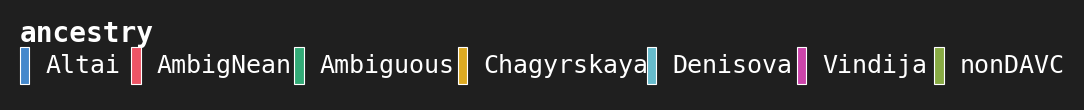

In [42]:
# tracks.zoom_to(**gene_view('MIR892B', span=1_000_000))
# tracks.zoom_to(**gene_view('ZFAS1', span=1_000_000))
# tracks.zoom_to(**gene_view('PTK2', span=1_000_000))
# tracks.zoom_to(**gene_view('DDX42', span=1_000_000))
tracks.clear_spans()
tracks.add_spans(spans,
                 color='white',
                    alpha=0.3,                                                          
                    edgewidth=2.0)

### Color by continuous variable

In [ ]:
Tracks('hg38').add_heatmap_track(
    segments, "mean_prob",
    individual_col="ind",
    value_col="mean_prob",
    palette="viridis",
    vmin=0.0, vmax=1.0, # optional; auto-inferred when omitted
)

### Color by discrete variable

In [ ]:
Tracks('hg38').add_heatmap_track(
    segments, "Ancestry",
    individual_col="ind",
    value_col="min_dist_anc",
)

Same but also rank using a `group_by`:

In [ ]:
Tracks('hg38').add_heatmap_track(
    segments, "Ancestry",
    individual_col="ind",
    value_col="min_dist_anc",
    group_by="reg",
)

### Legend

You can add a legend for tracks with continuous coloring.

In [ ]:
Tracks('hg38').add_heatmap_track(
    segments, "mean_prob",
    individual_col="ind",
    value_col="mean_prob",
    palette="viridis",
    vmin=0.0, vmax=1.0,
).add_heatmap_track(
    segments, "length",
    individual_col="ind",
    value_col="length",
    palette='plasma',
).legend("mean_prob", "length")


## Segment tracks

FIXME: with `group_by='ancestry', individual_col='ind'` the segment view is non-sensical

Stacked segment density / segment view track:

In [ ]:
(
    Tracks('hg38')
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', 
        group_by='ancestry', individual_col='ind', 
        height=60,
    )   
)

Or not stacked etc.:

In [ ]:
(
    Tracks('hg38')
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', group_by='ancestry', individual_col='ind', height=80,
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        density_windows=(512, 2048, 8192),
    )   
)

## Data tracks

### Point plot

In [ ]:
Tracks('hg38').add_point_track(
        qdf, 'Scatter', x='pos', y='fst', group_by='pop',
        tip_fmt=False,
    )


### Line plot

In [ ]:
Tracks('hg38').add_line_track(
        qdf, 'Lines', x='pos', y='rate', group_by='pop',
        step='post', 
        tip_fmt=False, height=60,
    )

### Fill plot

In [ ]:
Tracks('hg38').add_fill_track(
        qdf, 'Fill btwn', x='pos', y_hi='ci_hi', y_lo='ci_lo', 
        group_by='pop', height=60, tip_fmt=False,
    )

### Histogram plot

In [ ]:
Tracks('hg38').add_histogram_track(
        qdf, 'Histogram', x='pos', y='depth', group_by='pop',
        stack=True,
        height=60, tip_fmt=False, 
    )

In [ ]:
(
    Tracks('hg38')
    .add_point_track(
        qdf, 'Scatter', x='pos', y='fst', group_by='pop', 
        tip_fmt=False,
    )
    .add_line_track(
        qdf, 'Lines', x='pos', y='rate', group_by='pop',
        step='post', tip_fmt=False, height=60,
    )
    .add_fill_track(
        qdf, 'Fill btwn', x='pos', y_hi='ci_hi', y_lo='ci_lo', 
        group_by='pop', height=60, tip_fmt=False,
    )
    .add_fill_track(
        qdf, 'Fill baseln', x='pos', y='eig', group_by='pop', 
        step='post', height=60, tip_fmt=False,
    )
    .add_histogram_track(
        qdf, 'Histogram', x='pos', y='depth', group_by='pop',
        stack=True,
        height=60, tip_fmt=False, 
    )
    .add_gene_track(height = 100)
)

### Arc plot

Draws a quadratic-Bezier arc between every pair of positions on the same chromosome. Apex height is fixed (clamped to the track band), so long arcs don't balloon off-screen. `group_by` colours the arcs; tooltip exposes `{group}`, `{pos1}`, `{pos2}`, `{span}`.

In [ ]:
rng = np.random.default_rng(7)
arc_rows = []
for chrom, csz in list(chrom_sizes.items())[:5]:
    n = 30
    p1 = rng.integers(0, csz, n)
    p2 = p1 + rng.integers(csz // 100, csz // 5, n)
    p2 = np.clip(p2, 0, csz - 1)
    kind = rng.choice(['cis', 'trans'], size=n, p=[0.7, 0.3])
    for a, b, k in zip(p1, p2, kind):
        arc_rows.append({'chrom': chrom, 'pos1': int(a), 'pos2': int(b), 'kind': k})
adf = pd.DataFrame(arc_rows)
adf

In [ ]:
Tracks('hg38').add_arc_track(
    adf, 'Interactions', group_by='kind',
    height=90, arc_height=60, alpha=0.85, line_width=1.8,
)

In [ ]:
"""
Gene sets for chromosome pairing, recombination, and non-homologous end joining.

Canonical HGNC symbols are used as the strings. Where a widely used alias differs
from the symbol, it is noted in a comment. Genes acting at multiple stages appear
in more than one list by design (e.g. MEIOB/SPATA22, BLM, EXO1, MRE11, RBBP8).
"""

# =============================================================================
# CHROMOSOME PAIRING (meiotic)
# =============================================================================

pairing_cohesion = [
    "SMC1B",   # SMC1-beta, meiosis-specific
    "SMC3",
    "RAD21",
    "RAD21L",  # RAD21L1
    "REC8",
    "STAG3",
    "STAG1",
    "STAG2",
    "NIPBL",
    "MAU2",
    "PDS5A",
    "PDS5B",
    "WAPL",
    "ESCO1",
    "ESCO2",
    "SGO1",
    "SGO2",
]

pairing_telomere_movement = [
    "SUN1",
    "SUN2",
    "SYNE1",
    "SYNE2",
    "KASH5",   # meiosis-specific KASH
    "TERB1",
    "TERB2",
    "MAJIN",
    "TERF1",   # TRF1
    "DYNC1H1",
]

pairing_axial_lateral = [
    "SYCP2",
    "SYCP3",
    "HORMAD1",
    "HORMAD2",
    "TRIP13",  # PCH2 ortholog
]

pairing_sc_central = [
    "SYCP1",
    "SYCE1",
    "SYCE1L",
    "SYCE2",
    "SYCE3",
    "TEX12",
    "SIX6OS1",  # C14orf39
]

pairing_synapsis_coordination = [
    "IHO1",     # CCDC36
    "ANKRD31",
    "MEIOB",
    "SPATA22",
]

# =============================================================================
# MEIOTIC RECOMBINATION
# =============================================================================

recomb_dsb_formation = [
    "SPO11",
    "TOPOVIBL",  # TOP6BL / C11orf80
    "REC114",
    "MEI4",
    "IHO1",      # CCDC36
    "ANKRD31",
    "MEI1",
    "PRDM9",
    "EWSR1",
    "CXXC1",
    "ZCWPW1",
    "ZCWPW2",
    "EHMT2",
]

recomb_resection = [
    "MRE11",
    "RAD50",
    "NBN",      # NBS1
    "RBBP8",    # CtIP
    "EXO1",
    "DNA2",
    "BLM",
]

recomb_strand_invasion = [
    "DMC1",
    "RAD51",
    "RPA1",
    "RPA2",
    "RPA3",
    "MEIOB",
    "SPATA22",
    "BRCA2",
    "PALB2",
    "BRCA1",
    "RAD51B",
    "RAD51C",
    "RAD51D",
    "XRCC2",
    "XRCC3",
    "SWSAP1",
    "ZSWIM7",   # SWS1
    "SPIDR",
    "PSMC3IP",  # HOP2
    "MND1",
    "RAD54L",
    "RAD54B",
    "RAD54L2",
    "FIGNL1",
    "FIRRM",    # FLIP / C1orf112
]

recomb_zmm_procrossover = [
    "MSH4",
    "MSH5",
    "TEX11",    # Zip4
    "SHOC1",    # Zip2 / C9orf84
    "SPO16",
    "HFM1",     # Mer3 helicase
    "RNF212",
    "RNF212B",
    "CCNB1IP1", # HEI10
]

recomb_resolution = [
    "MLH1",
    "MLH3",
    "EXO1",
    "MUS81",
    "EME1",
    "EME2",
    "SLX1A",
    "SLX1B",
    "SLX4",
    "GEN1",
    "BLM",
    "TOP3A",
    "RMI1",
    "RMI2",
    "FANCM",
    "RTEL1",
]

recomb_mismatch_repair = [
    "MSH2",
    "MSH3",
    "MSH6",
    "PMS2",
    "PMS1",
]

recomb_checkpoint = [
    "ATM",
    "ATR",
    "TRIP13",
    "HORMAD1",
    "HORMAD2",
]

# =============================================================================
# NON-HOMOLOGOUS END JOINING (NHEJ)
# =============================================================================

nhej_recognition = [
    "XRCC6",   # Ku70
    "XRCC5",   # Ku80
    "PRKDC",   # DNA-PKcs
]

nhej_end_processing = [
    "DCLRE1C", # Artemis
    "POLM",    # Pol mu
    "POLL",    # Pol lambda
    "DNTT",    # TdT
    "PNKP",
    "APLF",
    "APTX",    # aprataxin
    "TDP1",
    "TDP2",
    "WRN",
]

nhej_ligation = [
    "LIG4",
    "XRCC4",
    "NHEJ1",   # XLF / Cernunnos
    "PAXX",    # C9orf142
]

nhej_pathway_choice = [
    "TP53BP1", # 53BP1
    "RIF1",
    "PAXIP1",  # PTIP
    "SHLD1",
    "SHLD2",   # FAM35A
    "SHLD3",
    "MAD2L2",  # REV7
    "DYNLL1",
    "CYREN",   # MRI / C7orf49
]

# Alternative end joining (alt-EJ / MMEJ / TMEJ) -- competing pathway
alt_ej = [
    "POLQ",    # Pol theta
    "PARP1",
    "LIG3",
    "LIG1",
    "XRCC1",
    "FEN1",
    "MRE11",
    "RBBP8",   # CtIP
]

# =============================================================================
# BROADER NON-HOMOLOGOUS DSB REPAIR
# Upstream sensing/signaling feeds all DSB repair; SSA is RAD51-independent
# but uses flanking direct repeats (homology-dependent, not conservative HR).
# =============================================================================

# Apical DSB sensing & signaling (triggers NHEJ and pathway choice)
dsb_sensing_signaling = [
    "ATM",
    "ATR",
    "PRKDC",   # DNA-PKcs
    "MRE11",   # MRN sensor
    "RAD50",
    "NBN",     # NBS1
    "H2AX",    # H2AFX
    "MDC1",
    "TP53BP1", # 53BP1
]

# Ubiquitin / chromatin signaling at the break
dsb_ubiquitin_chromatin = [
    "RNF8",
    "RNF168",
    "UBE2N",    # UBC13
    "HERC2",
    "UIMC1",    # RAP80
    "ABRAXAS1", # FAM175A
    "BABAM1",
    "BABAM2",   # BRE
    "BRCC3",
    "BRE",
    "RNF4",
]

# Single-strand annealing (SSA) -- RAD51-independent, uses flanking repeats
ssa = [
    "RAD52",
    "RPA1",
    "RPA2",
    "RPA3",
    "MRE11",
    "RBBP8",   # CtIP
    "ERCC1",
    "ERCC4",   # XPF
    "SLX4",
    "LIG1",
    "LIG3",
]

# =============================================================================
# SEX CHROMOSOME-SPECIFIC PAIRING & SEGREGATION
# Acting during/after PRDM9 binding. These are functionally specific to the
# sex chromosomes (PAR pairing, MSCI / sex-body, postmeiotic sex chromatin),
# NOT general meiotic genes that merely happen to be X/Y-linked.
# =============================================================================

# PRDM9-site effectors / readers acting *after* PRDM9 deposits H3K4me3/H3K36me3.
# Genome-wide (not sex-specific), but they define the "after PRDM9 binding"
# window in which the PAR must acquire its obligate DSB. Included for context.
prdm9_post_binding_readers = [
    "ZCWPW1",   # reads dual H3K4me3/H3K36me3 at hotspots
    "ZCWPW2",
    "CXXC1",    # links PRDM9 sites to the chromosome axis
    "HELLS",    # chromatin remodeling at hotspots
    "EWSR1",
]

# X-Y pairing & the obligate pseudoautosomal (PAR) crossover.
# ANKRD31 is the PAR-preferential factor; the others are PAR-enriched but
# also act genome-wide.
xy_par_pairing = [
    "ANKRD31",  # PAR-specific DSB / recombination control
    "SPO11",
    "REC114",
    "MEI4",
    "IHO1",     # CCDC36
]

# Meiotic sex chromosome inactivation (MSCI) / sex-body (XY-body) formation.
# ATR-TOPBP1 recruited to unsynapsed axes -> gamma-H2AX spreading -> silencing.
msci_sex_body = [
    "ATR",
    "ATRIP",
    "TOPBP1",
    "HORMAD1",
    "HORMAD2",
    "MDC1",
    "H2AX",     # H2AFX (gamma-H2AX)
    "BRCA1",
    "SETX",     # senataxin
    "TRIP13",
]

# Postmeiotic sex chromatin (PMSC) maintenance & escape regulation.
pmsc_silencing = [
    "SCML2",    # X-linked Polycomb; sex-chromosome gene regulation
    "RNF8",     # ubiquitination -> escape-gene activation on sex body
    "UBR2",     # H2A ubiquitination on the sex body
    "USP7",
    "HUWE1",    # X-linked
    "SETDB1",   # H3K9me3 on postmeiotic sex chromatin
    "MORC1",
]

# Sex-chromosome intragenomic conflict / transmission-ratio distortion.
# Mouse ampliconic X/Y gene families regulating PMSC; no clean 1:1 human
# orthologs. Slx/Slxl1 (X) vs Sly (Y) antagonism biases offspring sex ratio.
xy_conflict_drive = [
    "Sly",      # mouse, Y ampliconic (represses PMSC genes)
    "Slx",      # mouse, X ampliconic (activates PMSC genes)
    "Slxl1",    # mouse, X ampliconic
    "Ssty1",    # mouse, Y ampliconic
    "Ssty2",    # mouse, Y ampliconic
    "Sstx",     # mouse, X ampliconic
    "Zfy1",     # mouse, Y; pachytene-checkpoint trigger if escaping MSCI
    "Zfy2",     # mouse, Y
]

# =============================================================================
# MITOCHONDRIAL: NUCLEAR CONTROL MACHINERY + OXPHOS MITO-NUCLEAR SUBUNITS
# The mtDNA genome encodes only 37 genes; control runs mostly nucleus->mito.
# Below are (a) nuclear factors that control mtDNA copy number / expression and
# (b) nuclear OXPHOS subunits that physically partner the mtDNA-encoded subunits
# of complexes I, III, IV, V (complex II is excluded: all-nuclear, no mtDNA part).
# =============================================================================

# Nuclear master regulators of mitochondrial biogenesis (control mtDNA via TFAM)
mtdna_biogenesis_regulators = [
    "PPARGC1A",  # PGC-1alpha
    "PPARGC1B",  # PGC-1beta
    "PPRC1",     # PRC
    "NRF1",
    "GABPA",     # NRF-2 alpha
    "GABPB1",    # NRF-2 beta
    "ESRRA",
    "YY1",
    "TFAM",      # also acts directly at mtDNA (packaging/transcription)
]

# Direct mtDNA replication & transcription machinery
mtdna_replication_transcription = [
    "POLG",
    "POLG2",
    "TWNK",      # Twinkle helicase (PEO1 / C10orf2)
    "SSBP1",     # mt single-strand DNA-binding protein
    "MGME1",
    "DNA2",
    "RNASEH1",
    "PRIMPOL",
    "TOP1MT",
    "TOP3A",
    "LIG3",      # mitochondrial DNA ligase isoform
    "POLRMT",    # mt RNA polymerase
    "TFB1M",
    "TFB2M",
    "TEFM",
    "MTERF1",
    "MTERF2",
    "MTERF3",
    "MTERF4",
]

# mt-RNA processing, stability, polyadenylation, degradation
mtdna_rna_processing = [
    "LRPPRC",
    "SLIRP",
    "ELAC2",     # RNase Z
    "TRMT10C",   # MRPP1
    "HSD17B10",  # MRPP2
    "PRORP",     # MRPP3 / mt RNase P
    "MTPAP",
    "PNPT1",
    "SUPV3L1",   # mt degradosome (SUV3)
    "FASTKD2",
    "GRSF1",
    "PTCD1",
    "PTCD2",
    "PTCD3",
    "DDX28",
    "NSUN4",
]

# Mitochondrial translation factors + tRNA modification (mt-gene expression)
mt_translation_factors = [
    "TUFM",
    "TSFM",
    "GFM1",
    "GFM2",
    "MTIF2",
    "MTIF3",
    "MTRF1",
    "MTRF1L",
    "MTRFR",     # C12orf65
    "MRRF",      # ribosome recycling factor
    "MTO1",
    "GTPBP3",
    "TRMU",      # MTU1
    "PUS1",
]

# Complex I (NADH:ubiquinone oxidoreductase) -- nuclear subunits.
# mtDNA partners: MT-ND1, MT-ND2, MT-ND3, MT-ND4, MT-ND4L, MT-ND5, MT-ND6
complex_I_nuclear = [
    "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4", "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8",
    "NDUFV1", "NDUFV2", "NDUFV3",
    "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA5", "NDUFA6", "NDUFA7", "NDUFA8", "NDUFA9",
    "NDUFA10", "NDUFA11", "NDUFA12", "NDUFA13", "NDUFAB1",
    "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5", "NDUFB6", "NDUFB7", "NDUFB8",
    "NDUFB9", "NDUFB10", "NDUFB11",
    "NDUFC1", "NDUFC2",
]

# Complex III (cytochrome bc1) -- nuclear subunits. mtDNA partner: MT-CYB
complex_III_nuclear = [
    "UQCRC1",
    "UQCRC2",
    "UQCRFS1",  # Rieske Fe-S
    "CYC1",
    "UQCRB",
    "UQCRH",
    "UQCRQ",
    "UQCR10",
    "UQCR11",
    "CYCS",     # cytochrome c (mobile carrier, not a fixed subunit)
]

# Complex IV (cytochrome c oxidase) -- nuclear subunits.
# mtDNA partners: MT-CO1, MT-CO2, MT-CO3
complex_IV_nuclear = [
    "COX4I1", "COX4I2",
    "COX5A", "COX5B",
    "COX6A1", "COX6A2", "COX6B1", "COX6B2", "COX6C",
    "COX7A1", "COX7A2", "COX7A2L", "COX7B", "COX7B2", "COX7C",
    "COX8A", "COX8C",
    "NDUFA4",   # reassigned from CI to CIV
]

# Complex V (F1Fo ATP synthase) -- nuclear subunits.
# mtDNA partners: MT-ATP6, MT-ATP8  (HGNC 2018 symbols; legacy in comments)
complex_V_nuclear = [
    "ATP5F1A",  # ATP5A1
    "ATP5F1B",  # ATP5B
    "ATP5F1C",  # ATP5C1
    "ATP5F1D",  # ATP5D
    "ATP5F1E",  # ATP5E
    "ATP5PB",   # ATP5F1
    "ATP5PD",   # ATP5H
    "ATP5PF",   # ATP5J
    "ATP5PO",   # ATP5O (OSCP)
    "ATP5MC1",  # ATP5G1
    "ATP5MC2",  # ATP5G2
    "ATP5MC3",  # ATP5G3
    "ATP5ME",   # ATP5I
    "ATP5MF",   # ATP5J2
    "ATP5MG",   # ATP5L
    "ATP5MJ",   # C14orf2 / 6.8PL
    "ATP5MK",   # ATP5MD / DAPIT
    "ATP5IF1",  # IF1 inhibitory factor (regulatory)
]

# =============================================================================
# GROUPED ACCESS + DEDUPLICATED MASTER SETS
# =============================================================================

GENE_SETS = {
    # pairing
    "pairing_cohesion": pairing_cohesion,
    "pairing_telomere_movement": pairing_telomere_movement,
    "pairing_axial_lateral": pairing_axial_lateral,
    "pairing_sc_central": pairing_sc_central,
    "pairing_synapsis_coordination": pairing_synapsis_coordination,
    # recombination
    "recomb_dsb_formation": recomb_dsb_formation,
    "recomb_resection": recomb_resection,
    "recomb_strand_invasion": recomb_strand_invasion,
    "recomb_zmm_procrossover": recomb_zmm_procrossover,
    "recomb_resolution": recomb_resolution,
    "recomb_mismatch_repair": recomb_mismatch_repair,
    "recomb_checkpoint": recomb_checkpoint,
    # nhej
    "nhej_recognition": nhej_recognition,
    "nhej_end_processing": nhej_end_processing,
    "nhej_ligation": nhej_ligation,
    "nhej_pathway_choice": nhej_pathway_choice,
    "alt_ej": alt_ej,
    # broader non-homologous DSB repair
    "dsb_sensing_signaling": dsb_sensing_signaling,
    "dsb_ubiquitin_chromatin": dsb_ubiquitin_chromatin,
    "ssa": ssa,
    # sex chromosome-specific
    "prdm9_post_binding_readers": prdm9_post_binding_readers,
    "xy_par_pairing": xy_par_pairing,
    "msci_sex_body": msci_sex_body,
    "pmsc_silencing": pmsc_silencing,
    "xy_conflict_drive": xy_conflict_drive,
    # mitochondrial: nuclear control machinery
    "mtdna_biogenesis_regulators": mtdna_biogenesis_regulators,
    "mtdna_replication_transcription": mtdna_replication_transcription,
    "mtdna_rna_processing": mtdna_rna_processing,
    "mt_translation_factors": mt_translation_factors,
    # mitochondrial: OXPHOS mito-nuclear subunits
    "complex_I_nuclear": complex_I_nuclear,
    "complex_III_nuclear": complex_III_nuclear,
    "complex_IV_nuclear": complex_IV_nuclear,
    "complex_V_nuclear": complex_V_nuclear,
}


def _union(*lists):
    """Order-preserving deduplicated union of gene lists."""
    seen, out = set(), []
    for lst in lists:
        for g in lst:
            if g not in seen:
                seen.add(g)
                out.append(g)
    return out


PAIRING_ALL = _union(
    pairing_cohesion,
    pairing_telomere_movement,
    pairing_axial_lateral,
    pairing_sc_central,
    pairing_synapsis_coordination,
)

RECOMBINATION_ALL = _union(
    recomb_dsb_formation,
    recomb_resection,
    recomb_strand_invasion,
    recomb_zmm_procrossover,
    recomb_resolution,
    recomb_mismatch_repair,
    recomb_checkpoint,
)

NHEJ_ALL = _union(
    nhej_recognition,
    nhej_end_processing,
    nhej_ligation,
    nhej_pathway_choice,
)

# All non-homologous / non-conservative DSB repair: c-NHEJ, alt-EJ, SSA,
# plus the upstream sensing and chromatin-signaling layer.
NON_HOMOLOGOUS_DSB_ALL = _union(
    nhej_recognition,
    nhej_end_processing,
    nhej_ligation,
    nhej_pathway_choice,
    alt_ej,
    dsb_sensing_signaling,
    dsb_ubiquitin_chromatin,
    ssa,
)

# Sex-chromosome-specific pairing & segregation (PAR, MSCI, PMSC, XY conflict).
# Excludes prdm9_post_binding_readers (genome-wide context, not sex-specific).
SEX_CHROMOSOME_ALL = _union(
    xy_par_pairing,
    msci_sex_body,
    pmsc_silencing,
    xy_conflict_drive,
)

# Nuclear machinery controlling mtDNA copy number, maintenance, and expression.
MTDNA_CONTROL_ALL = _union(
    mtdna_biogenesis_regulators,
    mtdna_replication_transcription,
    mtdna_rna_processing,
    mt_translation_factors,
)

# Nuclear OXPHOS subunits partnering mtDNA-encoded subunits (complexes I/III/IV/V).
OXPHOS_NUCLEAR_ALL = _union(
    complex_I_nuclear,
    complex_III_nuclear,
    complex_IV_nuclear,
    complex_V_nuclear,
)

ALL_GENES = _union(
    PAIRING_ALL,
    RECOMBINATION_ALL,
    NON_HOMOLOGOUS_DSB_ALL,
    SEX_CHROMOSOME_ALL,
    MTDNA_CONTROL_ALL,
    OXPHOS_NUCLEAR_ALL,
)


# if __name__ == "__main__":
#     for name, genes in GENE_SETS.items():
#         print(f"{name:32s} {len(genes):3d}")
#     print("-" * 40)
#     print(f"{'PAIRING_ALL':32s} {len(PAIRING_ALL):3d}")
#     print(f"{'RECOMBINATION_ALL':32s} {len(RECOMBINATION_ALL):3d}")
#     print(f"{'NHEJ_ALL':32s} {len(NHEJ_ALL):3d}")
#     print(f"{'NON_HOMOLOGOUS_DSB_ALL':32s} {len(NON_HOMOLOGOUS_DSB_ALL):3d}")
#     print(f"{'SEX_CHROMOSOME_ALL':32s} {len(SEX_CHROMOSOME_ALL):3d}")
#     print(f"{'MTDNA_CONTROL_ALL':32s} {len(MTDNA_CONTROL_ALL):3d}")
#     print(f"{'OXPHOS_NUCLEAR_ALL':32s} {len(OXPHOS_NUCLEAR_ALL):3d}")
#     print(f"{'ALL_GENES (unique)':32s} {len(ALL_GENES):3d}")

from geneinfo.information import gene_coords_region
from geneinfo.genelist import GeneList as glist
chr3_reg_genes = glist([x[0] for x in gene_coords_region('chr3', 41_000_000, 53_000_000, assembly='hg38')])

for name, genes in GENE_SETS.items():
    genes = glist(genes)
    ovl = chr3_reg_genes & genes
    if ovl:
        print(name, chr3_reg_genes & genes)

#glist(chr3_reg_genes) << glist(['HYAL3', 'HEMK1', 'HYAL1', 'IHO1', 'KIF9', 'MAPKAPK3', 'PHF7', 'SMARCC1', 'ZMYND10'])

In [33]:
from geneinfo.information import gene_info
from collections import defaultdict
spans = defaultdict(list)
for chrom, start, end, _ in gene_coords(['ATRIP', 'IHO1', 'RAD54L2', 'UQCRC1'], assembly='hg38'):
    spans[chrom].append((start, end))
spans

defaultdict(list,
            {'chr3': [(48446736, 48467645),
              (49191308, 49258106),
              (51538718, 51668660),
              (48599001, 48609646)]})

## Cross-track annotation

You can add vertical lines and boxes representing additional meta data. When experimenting with large data sets, you can load the widget once and assign to a variable to avoid loading again when updating annotation (in the cell below).

In [ ]:
tracks = (
    Tracks('hg38')
    .add_arc_track(
        adf, 'Interactions', group_by='kind',
        height=90, arc_height=60, alpha=0.85, line_width=1.8,
    )    
    .add_point_track(
        qdf, 'Scatter', x='pos', y='fst', group_by='pop', 
        tip_fmt=False,
    )
    .add_line_track(
        qdf, 'Lines', x='pos', y='rate', group_by='pop',
        step='post', tip_fmt=False, height=60,
    )
    .add_fill_track(
        qdf, 'Fill btwn', x='pos', y_hi='ci_hi', y_lo='ci_lo', 
        group_by='pop', height=60, tip_fmt=False,
    )
    .add_fill_track(
        qdf, 'Fill baseln', x='pos', y='eig', group_by='pop', 
        step='post', height=60, tip_fmt=False,
    )
    .add_histogram_track(
        qdf, 'Histogram', x='pos', y='depth', group_by='pop',
        stack=True,
        height=60, tip_fmt=False, 
    )
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', 
        group_by='ancestry', individual_col='ind', height=50,
    )       
    .add_heatmap_track(
        segments, "mean_prob",
        individual_col="ind",
        value_col="mean_prob",
        palette="viridis",
        vmin=0.0, vmax=1.0,
    )
    .add_heatmap_track(
        segments, "length",
        individual_col="ind",
        value_col="length",
        palette='plasma',
    )
    # .add_gene_track(height = 100)
    .add_gene_track(label_padding=1000)
)
tracks.zoom_to('chr3', center=41_000_000, window=53_000_000)
tracks

Now you can add lines. The widget above updates every time you execute the cell below. Add a semicolon after the last `add_spans` call to suppress also rendering the widget below the cell.

In [ ]:
tracks.clear_vlines()   

# dict style
tracks.add_vlines({'chr1': [50_000_000, 60_000_000], 'chr2': [3_000_000]}, color='red', alpha=0.5, linewidth=2, dash=[4, 3]) ;

# arg, kwarg style
tracks.add_vlines([10_000_000, 20_000_000], chrom='chr1', ) ;


You can add shaded regions/spans in similar way:

In [ ]:
tracks.clear_spans() 

# dict form: multiple chromosomes at once
tracks.add_spans({'chr1': [(160e6, 200e6)], 'chr2': [(5e6, 6e6)]}) ;

# elaborate styling
tracks.add_spans({'chr1': [(220e6, 240e6)], 'chr2': [(5e6, 6e6)]},
                    color='none', alpha=0.2,                                                          
                    edgecolor='red', edgewidth=3.0, 
                    dash=[4, 3]
                 ) ;  

# single span                                                                                          
tracks.add_spans((50_000_000, 70_000_000), chrom='chr1', color='C1') ;                                  
                                                                                                        
# multiple spans                                                                                       
tracks.add_spans([(60_000_000, 110_000_000), (120_000_000, 130_000_000)]) ;                                                                                                        

## Removing tracks

`Tracks` now has `remove_track(name_or_index)` and `clear_tracks()`:

- `remove_track('Scatter')` removes the single track named `'Scatter'`; raises `KeyError` if no track matches.
- `remove_track(0)` removes the first track by positional index.
- `clear_tracks()` drops every track (the viewer remains live and you can add new tracks to it).

Both return `self` so you can chain further updates, and both also release the track's GPU resources on the JS side, so re-running the same cell does not leak VRAM.

In [ ]:
# Build a viewer with two tracks, then remove one.
demo = (
    Tracks('hg38')
    .add_point_track(qdf, 'Scatter', x='pos', y='fst', group_by='pop', tip_fmt=False)
    .add_line_track (qdf, 'Lines',   x='pos', y='rate', group_by='pop', tip_fmt=False, step='post')
    .add_gene_track(height=100)
)
# Drop the line track by name and keep chaining:
demo.remove_track('Lines')
demo

In [ ]:
# Start over on the same viewer:
demo.clear_tracks().add_gene_track(height=60, highlight=['BRCA1', 'TP53'])
demo

## Programmatic zoom

Useful for setting some view you want to fix:

In [ ]:
tracks = (
    Tracks('hg38').add_point_track(
        qdf, 'GWAS -log10(p)', x='pos', y='fst', group_by='pop', tip_fmt=False,
    )
    .add_gene_track(label_padding=1000)
)

tracks.zoom_to('chr1', center=50_000_000, window=20_000_000)

## Tooltips

Each track contributes to the cursor tooltip unless `tip_fmt=False`. Use `tip_fmt` to control what each track contributes to the tooltip. Format placeholders use Python-style `{key}` or `{key:.Nf}` syntax.

Available keys per track type:
- **Gene**: `name`, `strand`, `start`, `end`
- **Scatter / Line**: `group`, `value`, `x`
- **Fill**: `group`, `lo`, `hi`, `x`
- **Histogram**: `group`, `value`, `x`
- **Segment**: `group`
- **Heatmap**: `group`, `individual`, `nInd`

If a format string references an invalid key, the tooltip shows the available keys as a hint.

In [ ]:
(
    Tracks(chrom_sizes)
    .add_point_track(
        qdf, 'Scatter', x='pos', y='fst', group_by='pop',
        tip_fmt="{value:.4f} is the value for {group}",
    )
    .add_line_track(
        qdf, 'Lines', x='pos', y='rate', group_by='pop',
        tip_fmt="For {group} the value is {value:.2f}",
    )
    .add_gene_track(
        assembly='hg38', height=44, 
        tip_fmt="The gene at this pos is {name}",
    )
)

## Using with `geneinfo`'s rewamped UCSC track support

In [ ]:
from geneinfo.widget import Tracks
import pandas as pd

from geneinfo.ucsc import (
    get_ucsc_track,                                                           
    get_ucsc_track_meta,
    search_ucsc_tracks,   
    list_ucsc_subtracks,                                                    
    UnsupportedTrackType,                              
)

In [ ]:
df = get_ucsc_track('gnomadConstraint', 'hg38',                               
                    chrom='chr1', start=10_000_000, end=15_000_000)           
                                                                            
list_ucsc_subtracks('dbSnp155Composite', 'hg38')                              

### Discover / search tracks

In [ ]:
                                                                         
# List everything for hg38 (long — pipe to a pager or filter first)
search_ucsc_tracks(assembly='hg38')                                           
                                                                            
# Fuzzy search                                                                
search_ucsc_tracks('gnomad constraint', assembly='hg38')                      
search_ucsc_tracks('recombination rate', assembly='hg38')                     
search_ucsc_tracks('gtex', assembly='hg38')
                                                                            
# Inspect a single track's metadata (type, longLabel, bigDataUrl, ...)        
get_ucsc_track_meta('gnomadConstraint', assembly='hg38')                      


In [ ]:
df_list = []
for base in ['A', 'T', 'G', 'C']:
    df = get_ucsc_track(f'alphaMissense_{base}', chrom='chrX', 
                        # start=10_000_000, end=11_000_000, 
                        assembly='hg38')  
    df['base'] = base                                                                              
    df_list.append(df)
alphaMissense = pd.concat(df_list)
#df.to_parquet('~/alphaMissense.parquet')       
alphaMissense.tail()

|  n   | binWidth_bp | binWidth_px at full-chrom view |
| ---- | ----------- | ------------------------------ |
| 64   |      3.9 Mb |                        15.6 px |
| 256  |      970 kb |                         3.9 px |
| 1024 |      243 kb |                        0.98 px |
| 4096 |       61 kb |                        0.24 px |

In [ ]:
# 1. Default LOD — (256, 1024, 4096) bins per chromosome                      
Tracks('hg38').add_ucsc_track('gnomadConstraint', chrom='chrX', kind='line').zoom_to('chrX')                                                                             

In [ ]:
# 4. Disable LOD entirely — ship every sample at every zoom                   
Tracks('hg38').add_ucsc_track(                                                
    'gnomadConstraint', chrom='chrX', kind='line',                          
    density_windows=(),
    ).zoom_to('chrX')    

In [ ]:
Tracks('hg38').add_ucsc_track('gnomadConstraint', chrom='chrX', kind='point').zoom_to('chrX')   


In [ ]:

Tracks('hg38').add_ucsc_track('gnomadConstraint', kind='point', chrom='chrX', value_col='value', palette='viridis').zoom_to('chrX')


In [ ]:
tracks = (
    Tracks('hg38')
    .add_ucsc_track('recombAvg', kind='line', chrom='chrX', color='C0')
    .add_ucsc_track('gnomadConstraint', kind='point', chrom='chrX')
    .add_ucsc_track('gtexCovBrainCortex', chrom='chrX', color='C1')
    .add_ucsc_track('gtexCovTestis', chrom='chrX', color='C2')
    .add_ucsc_track('gtexTranscExpr', kind='point', chrom='chrX', color='C3')
    .add_point_track(alphaMissense, 'alphaMissense', x='start', y='value', value_col='base')
    .add_heatmap_track(
        segments, "mean_prob",
        individual_col="ind",
        value_col="mean_prob",
        palette="viridis",
        vmin=0.0, vmax=1.0,
    ).add_heatmap_track(
        segments, "length",
        individual_col="ind",
        value_col="length",
        palette='plasma',
    ).add_gene_track()
).zoom_to('chrX') 


In [ ]:

tracks.add_vlines({'chr1': [50_000_000, 60_000_000], 'chr2': [3_000_000]}, color='red', alpha=0.5, linewidth=2, dash=[4, 3]) ;
tracks.add_spans({'chr1': [(220e6, 240e6)], 'chr2': [(5e6, 6e6)]},
                    color='none', alpha=0.2,                                                          
                    edgecolor='red', edgewidth=3.0, 
                    dash=[4, 3]
                 ) ;                                                                                                          
tracks.add_spans([(60_000_000, 110_000_000), (120_000_000, 130_000_000)]) 
tracks  


# Try to make a alphaMissense/cons30way or something track to find regions unconserved dispite being pathogenic

# iPlot

make sure variables are taken from OPTIONS:

```python
OPTIONS = dict(
    default_height=5,
    max_figure_width=10, 
    max_figure_height=5,
    max_facet_height = 3
    min_facet_height = 2
    theme = dict(style='darkgrid', palette='viridis'),
    graphics=AXIS_LEVEL_GRAPHICS
    )

max_facet_height = OPTIONS['max_facet_height']
min_facet_height = OPTIONS['min_facet_height']
default_height = OPTIONS['default_height']
```

In [ ]:
import iplot
import importlib
importlib.reload(iplot)
#iplot.iplot_settings(default_height=1)

In [ ]:
iplot.iplot_settings(max_facet_height=1.5, min_facet_height=1, default_height=2)
import matplotlib
matplotlib.rcdefaults()
matplotlib.rc('font', size=4)
iplot.iplot(segments)

rc = {'font.size': 4}
with matplotlib.rc_context(rc):
    print(matplotlib.rcParams)
    iplot.iplot(segments)

In [ ]:
f'{segments=}'.split('=')[0]

In [ ]:
matplotlib.rc_params().get('font.size')

In [ ]:
matplotlib.rc('font', size=4)

In [ ]:
data = segments
import seaborn as sns
sns.set_style({'style': 'darkgrid', 'palette': 'viridis'})                             
g = sns.displot(data, x='chrom', height=4, kind='hist')
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.tight_layout()

# upgrade vscode to get to return the background color

In [ ]:
import matplotlib.pyplot as plt
from geneinfo.plot import upset
from vscodenb import set_vscode_theme, is_vscode_dark_theme
set_vscode_theme()
is_vscode_dark_theme()  

In [ ]:
from geneinfo.genelist import GeneList as glist
from geneinfo.genelist import GeneListCollection
sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')

In [ ]:
upset({
    'A': set(sheet.get('cDEG')), 
    'B': set(sheet.get('nDEG'))
    })

In [ ]:
cDEG = sheet.get('cDEG')
cDEG

In [ ]:
upset([
    sheet.get('cDEG'), 
    sheet.get('nDEG')
    ])